# 📊 Customer Churn Prediction

## 🎯 Objective
Predict whether a customer will churn and extract actionable business insights.

---

## 💼 Business Context
Customer churn leads to revenue loss.  
By predicting churn early, companies can:
- Retain high-risk customers
- Reduce marketing costs
- Improve customer lifetime value

🟦 1) Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix

import joblib

### 🧠 Insight:
We import all tools required for data analysis, modeling, and evaluation.

🟦 2) Load Data

In [2]:
df = pd.read_csv(r"C:\Users\mahmu\OneDrive\Desktop\Telco Customer Churn\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 🧠 Insight:
Initial inspection helps understand structure and feature types.

🟦 3) Data Understanding

We explore the dataset to understand:
- Data types
- Missing values
- Feature structure
- Missing values
- Statistical summary


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 🧠 Insights:
- Some columns contain missing values
- `TotalCharges` needs conversion
- Dataset contains mixed data types

🟦 4) Data Cleaning

🔹 Convert TotalCharges

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)
df.drop("customerID", axis=1, inplace=True)

### 🧠 Insight:
Clean data ensures better model performance and avoids errors.

🟦 5) Encoding

In [5]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})
df = pd.get_dummies(df, drop_first=True)

### 🧠 Insight:
Machine learning models require numerical inputs.

🟦 6) EDA

🔹Target Distribution

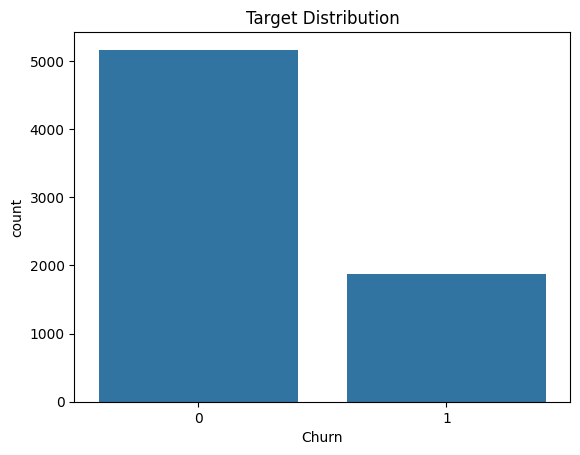

In [6]:
sns.countplot(x="Churn", data=df)
plt.title("Target Distribution")
plt.show()

### 🧠 Insight:
Dataset is **imbalanced** → critical for modeling decisions.

🔹Correlation

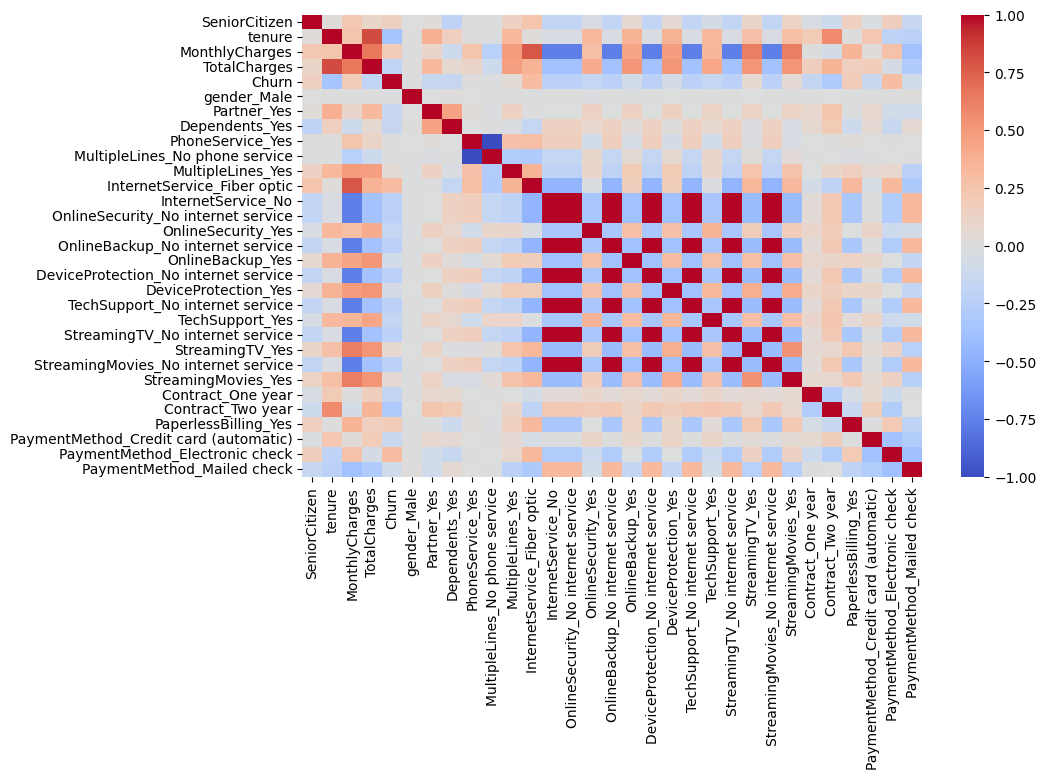

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

🟦 7) Feature Engineering

In [8]:
df["AvgCharge"] = df["TotalCharges"] / (df["tenure"] + 1)
df["IsNew"] = (df["tenure"] < 12).astype(int)
df["HighCharges"] = (df["MonthlyCharges"] > 80).astype(int)

### 🧠 Insight:
New features improve model understanding and capture hidden patterns.

🟦 8) Split Data

In [9]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

🟦 9) Scaling

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

🟩 10) Logistic Regression

In [11]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



### 🧠 Insight:
Baseline model — good recall but limited flexibility.

🟩 11) Decision Tree

In [12]:
tree_model = DecisionTreeClassifier(
    max_depth=3,
    class_weight="balanced",
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.92      0.55      0.69      1033
           1       0.41      0.87      0.56       374

    accuracy                           0.64      1407
   macro avg       0.67      0.71      0.63      1407
weighted avg       0.79      0.64      0.66      1407



### 🧠 Insight:
Captures non-linear relationships but prone to overfitting.

🟩 12) Random Forest

In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.54      0.71      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407



### 🧠 Insight:
Best balance between bias and variance.

## ⚖️ Model Comparison

- Logistic Regression: High recall, low precision
- Decision Tree: Overfits easily
- Random Forest: Best balance and stability

### 🧠 Decision:
Random Forest selected as final model

🧠 13) Feature Importance

In [14]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

tenure                            0.141494
TotalCharges                      0.118105
MonthlyCharges                    0.095394
AvgCharge                         0.087709
InternetService_Fiber optic       0.074772
Contract_Two year                 0.073718
IsNew                             0.055594
PaymentMethod_Electronic check    0.048435
Contract_One year                 0.034032
TechSupport_Yes                   0.024398
dtype: float64

## 📊 Feature Importance Insights

- Customers with low tenure are more likely to churn
- High monthly charges increase churn probability
- Long-term contracts reduce churn risk

### 💼 Business Interpretation:
- Focus retention campaigns on new customers
- Offer discounts for high-paying customers
- Encourage long-term contracts

🔹Visualization

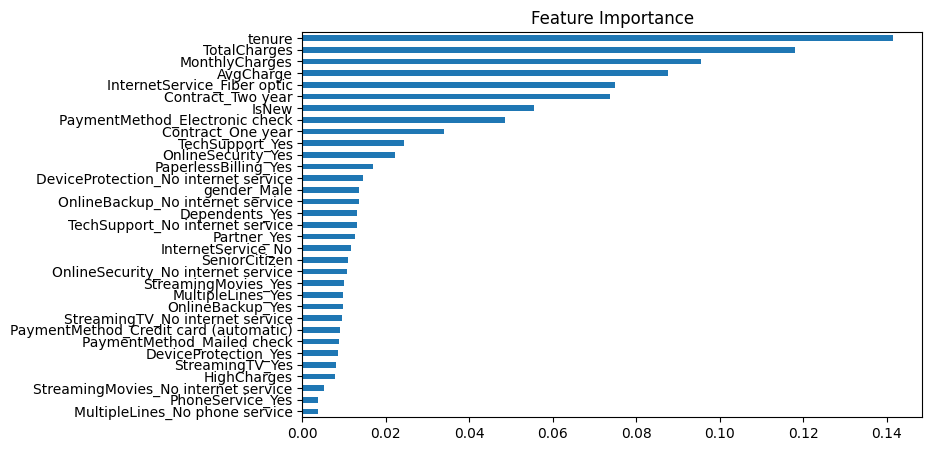

In [15]:
importances.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance")
plt.show()

### 🧠 Insights:
- Tenure is the most important factor
- Pricing strongly influences churn

🟦 14) Feature Selection

In [16]:
important_features = importances[importances > 0.02].index

X_new = X[important_features]

🔹Retrain Model

In [17]:
X_train_new, X_test_new, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

rf_new = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf_new.fit(X_train_new, y_train)

y_pred_new = rf_new.predict(X_test_new)

print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.87      0.78      0.83      1033
           1       0.54      0.69      0.60       374

    accuracy                           0.76      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.78      0.76      0.77      1407



🟦 15) Cross Validation

In [18]:
scores = cross_val_score(rf_new, X_new, y, cv=5, scoring="f1")

print(scores)
print(scores.mean())

[0.64053751 0.64285714 0.58041958 0.61065089 0.61519608]
0.6179322406559642


### 🧠 Insight:
Model is stable and generalizes well.

🟦 16) Hyperparameter Tuning

In [19]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


🟦 17) Best Model

In [20]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.54      0.71      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407



🟦 18) Threshold Tuning 🔥

In [21]:
y_probs = best_rf.predict_proba(X_test)[:,1]

for t in [0.4, 0.5, 0.6, 0.7]:
    y_pred_new = (y_probs > t).astype(int)
    print(f"Threshold: {t}")
    print(classification_report(y_test, y_pred_new))

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.91      0.69      0.78      1033
           1       0.49      0.80      0.60       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.69      1407
weighted avg       0.79      0.72      0.74      1407

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.54      0.71      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407

Threshold: 0.6
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1033
           1       0.59      0.61      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.73      1407
weighted avg       0.79      

### 🧠 Insight: 🎚️ Threshold Optimization
Threshold controls trade-off between precision and recall.

Different thresholds were tested:

- 0.4 → High recall, many false positives
- 0.5 → Best balance (selected)
- 0.6 → High precision, misses churn cases

### 🎯 Final Decision:
Threshold = 0.5

🟩 19) Final Model

In [22]:
threshold = 0.5

y_pred_best = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.54      0.71      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407



🟥 20) Confusion Matrix

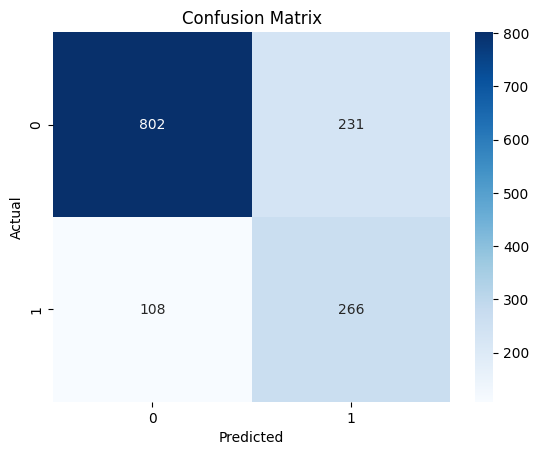

In [23]:
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 🏁 Final Conclusion

This project successfully built an end-to-end machine learning pipeline to predict customer churn, combining data analysis, feature engineering, model optimization, and business interpretation.

---

## 📊 Key Findings

- The dataset was imbalanced → handled effectively using `class_weight="balanced"`
- Feature engineering improved model understanding and predictive power
- Random Forest outperformed other models due to its ability to capture non-linear relationships
- Threshold tuning played a critical role in balancing precision and recall

---

## 🤖 Final Model

**Random Forest (Tuned)**

### Best Parameters:
- n_estimators = 200  
- max_depth = 10  
- min_samples_split = 5  

### Decision Threshold:
- **0.5 (selected for best balance)**

---

## 📈 Final Performance

| Metric     | Score |
|------------|------|
| Precision  | 0.54 |
| Recall     | 0.71 |
| F1-score   | 0.61 |

---

## 💼 Business Impact

- 🎯 Identify high-risk customers early  
- 💰 Reduce revenue loss due to churn  
- 📉 Optimize marketing and retention strategies  
- 🤝 Improve customer satisfaction and engagement  

---

## 🧠 Key Insight

> Customer churn is strongly influenced by tenure, pricing, and contract type.

- New customers are more likely to churn  
- High charges increase churn probability  
- Long-term contracts significantly reduce churn  

---

## 🚀 Final Takeaway

This project demonstrates that:

- Model performance is not just about accuracy  
- Handling imbalance and tuning thresholds are critical  
- Feature engineering significantly impacts results  
- Machine learning must be aligned with business objectives  
